# Heart Disease Prediction Project
## End-to-End Machine Learning Pipeline & Comparative Analysis

### Project Objective
The main goal of this project is to build a complete Machine Learning pipeline for predicting heart disease using multiple classification algorithms.

This project follows the required stages of a real-world machine learning workflow:
- Data Collection
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Scaling
- Model Training
- Model Evaluation
- Comparative Analysis

The project also compares multiple machine learning models to determine the best-performing algorithm for heart disease prediction.


# Import Required Libraries

In this section, we import all the required libraries for:
- Data manipulation
- Data visualization
- Machine learning
- Model evaluation


In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Helper: nicely print metrics and report
def print_metrics(name, y_true, y_pred):
    print(f"=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred))


# Load Dataset

The dataset used in this project is the Heart Disease UCI dataset.

The dataset contains medical information about patients such as:
- Age
- Cholesterol
- Blood Pressure
- Chest Pain Type
- Maximum Heart Rate
- ECG Results

The target variable determines whether the patient has heart disease or not.


In [2]:
df = pd.read_csv(r'C:\Users\moham\OneDrive - Assuit University\Desktop\Third Project\heart_disease_uci.csv')

df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# Dataset Shape

Understanding the shape of the dataset helps determine:
- Number of rows (samples)
- Number of columns (features)


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 920
Columns: 16


In [4]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Helper: nicely print metrics and report
def print_metrics(name, y_true, y_pred):
    print(f"=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred))


In [5]:
df.isnull().sum()


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

# Handling Missing Values

## Numerical Features
For numerical columns, missing values are replaced using the median value because it is less sensitive to outliers.

## Categorical Features
For categorical columns, missing values are replaced using the mode (most frequent value).


In [6]:
# Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

# Target Variable Preparation

The dataset contains multiple classes for heart disease severity.

For simplicity and better classification performance, the problem is converted into binary classification:

- 0 → No Heart Disease
- 1 → Heart Disease


In [7]:
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

df['num'].value_counts()


num
1    509
0    411
Name: count, dtype: int64

# Target Distribution Visualization

This visualization shows the number of patients with and without heart disease.


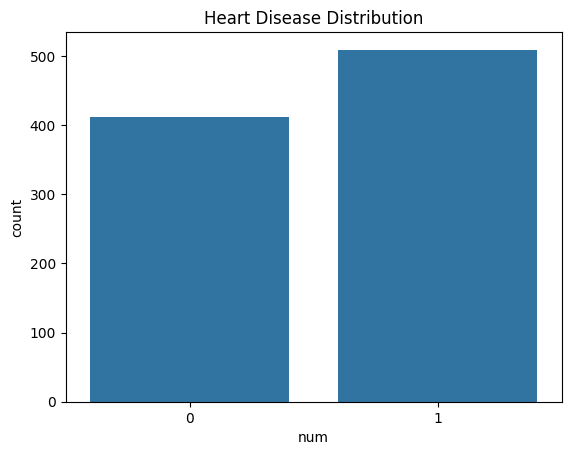

In [8]:
sns.countplot(x='num', data=df)
plt.title('Heart Disease Distribution')
plt.show()


# Encoding Categorical Features

Machine Learning models cannot work directly with text values.

Therefore, categorical columns are converted into numerical values using Label Encoding.


In [9]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


# Exploratory Data Analysis (EDA)

EDA is important for:
- Understanding feature distributions
- Detecting outliers
- Identifying relationships between variables
- Understanding correlations


## Histograms

Histograms help visualize the distribution of numerical features.


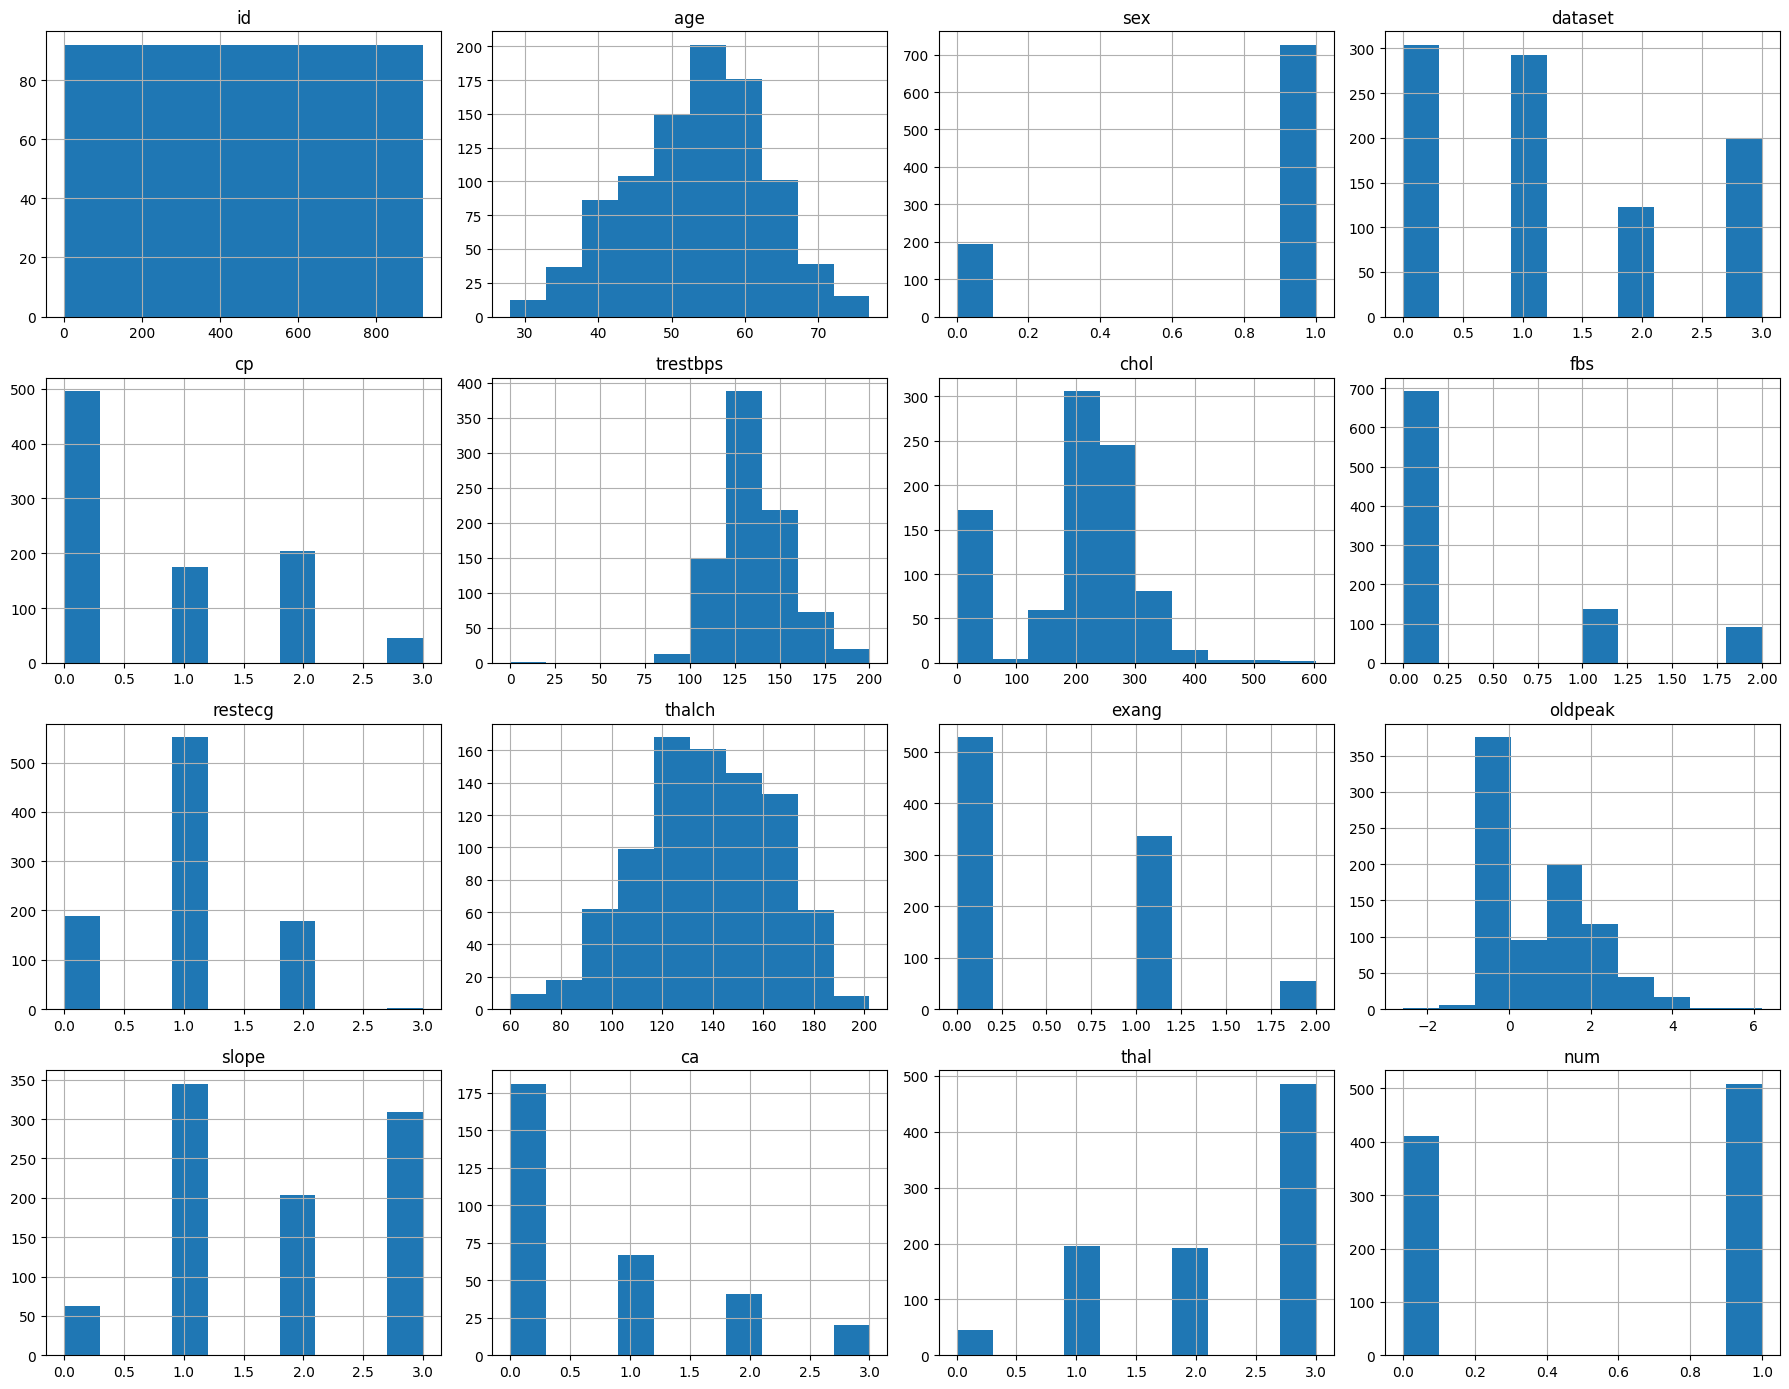

In [10]:
df.hist(figsize=(18,14))
plt.tight_layout()
plt.show()


## Correlation Matrix

The correlation matrix shows the relationship between variables.

Positive values indicate positive correlation, while negative values indicate inverse correlation.


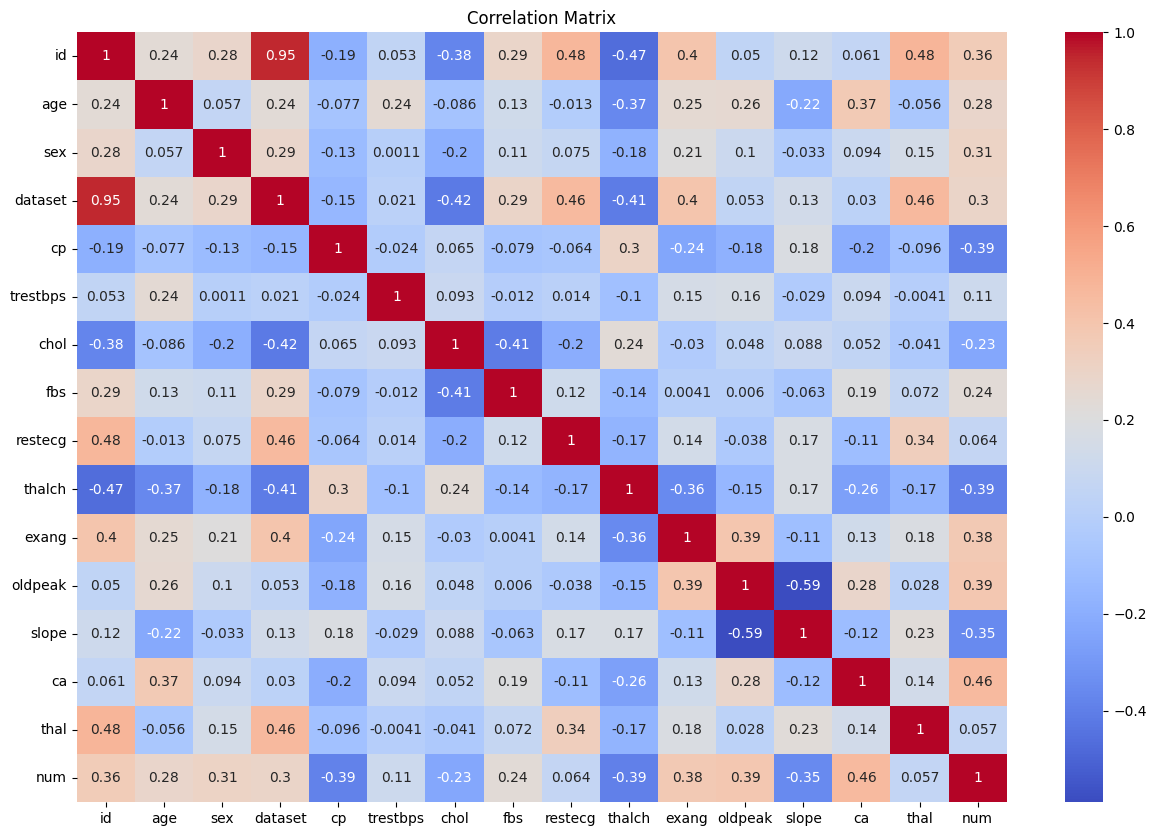

In [11]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


## Scatter Plot

This scatter plot shows the relationship between age and cholesterol levels.


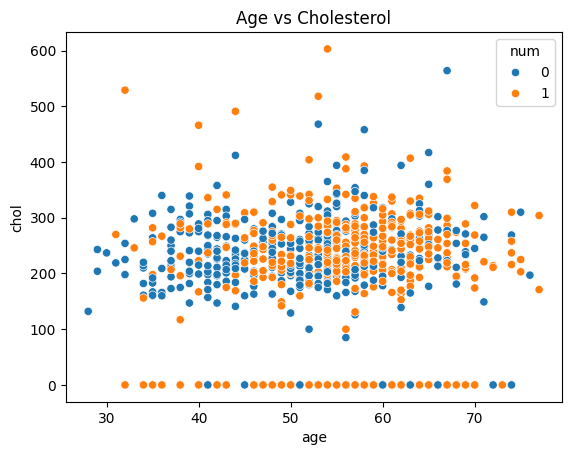

In [12]:
sns.scatterplot(x='age', y='chol', hue='num', data=df)
plt.title('Age vs Cholesterol')
plt.show()


## Outlier Detection & Statistical Analysis

Boxplots are effective for detecting outliers in continuous features. This visualization helps identify data points that deviate significantly from the central distribution, which could indicate measurement errors or extreme cases requiring special handling.

For this project, outliers are retained for analysis as they represent genuine medical cases (e.g., extremely high cholesterol levels are medically relevant for heart disease prediction).

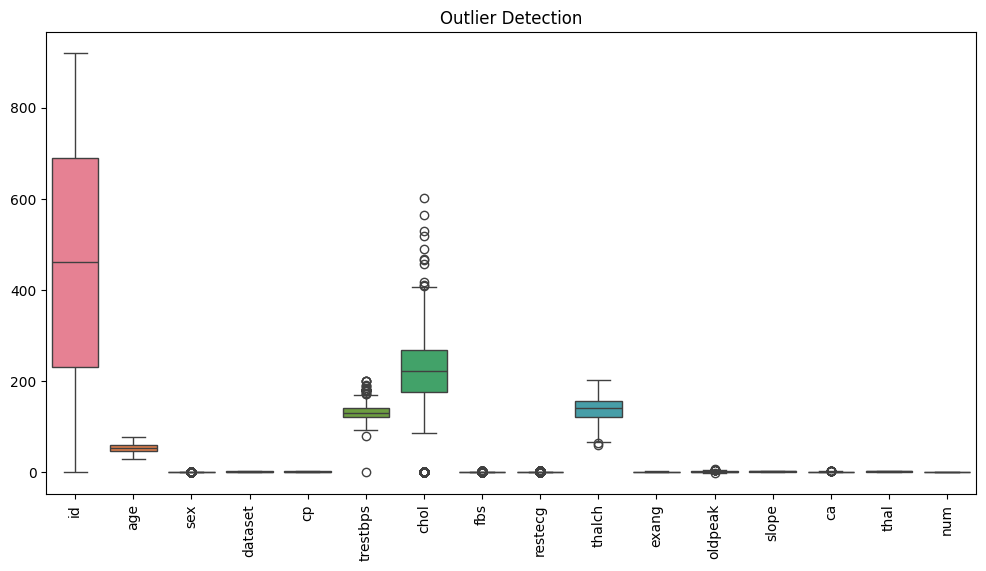

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title('Outlier Detection')
plt.show()


# Feature Selection

The dataset is divided into:
- Features (X)
- Target variable (y)


In [14]:
# Separate features (X) and target (y) variables
X = df.drop('num', axis=1)
y = df['num']

# Convert all feature columns to numeric type (invalid entries become NaN)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill missing values in numeric columns with their median (robust to outliers)
for col in X.select_dtypes(include=[np.number]).columns:
    X[col].fillna(X[col].median(), inplace=True)

# Fill missing values in categorical columns with their mode (most frequent value)
for col in X.select_dtypes(exclude=[np.number]).columns:
    X[col].fillna(X[col].mode()[0], inplace=True)

In [15]:
print('Missing values after imputation (features):')
print(X.isnull().sum())
print('\nAny NaN in X:', X.isnull().any().any())

print('\nColumn medians and non-null counts:')
for col in X.columns:
    non_null = X[col].notnull().sum()
    med = X[col].median()
    print(f"{col}: non-null={non_null}, median={med}")


Missing values after imputation (features):
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs           0
restecg       0
thalch       55
exang         0
oldpeak      62
slope         0
ca          611
thal          0
dtype: int64

Any NaN in X: True

Column medians and non-null counts:
id: non-null=920, median=460.5
age: non-null=920, median=54.0
sex: non-null=920, median=1.0
dataset: non-null=920, median=1.0
cp: non-null=920, median=0.0
trestbps: non-null=861, median=130.0
chol: non-null=890, median=223.0
fbs: non-null=920, median=0.0
restecg: non-null=920, median=1.0
thalch: non-null=865, median=140.0
exang: non-null=920, median=0.0
oldpeak: non-null=858, median=0.5
slope: non-null=920, median=2.0
ca: non-null=309, median=0.0
thal: non-null=920, median=3.0


In [16]:
# Additional safety check: ensure NO remaining NaN values (critical for ML models)
for col in X.columns:
    if X[col].isnull().any():
        # For numeric columns, use median as it's resistant to outliers
        if X[col].dtype.kind in 'biufc':
            X[col] = X[col].fillna(X[col].median())
        # For categorical, use mode (most frequent value)
        else:
            X[col] = X[col].fillna(X[col].mode()[0])

print('\nMissing values after final imputation pass:')
print(X.isnull().sum())


Missing values after final imputation pass:
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


# Feature Scaling

Feature scaling is important because some machine learning algorithms such as:
- KNN
- SVM

are sensitive to differences in feature scales.

StandardScaler standardizes all features to have:
- Mean = 0
- Standard Deviation = 1


In [17]:
# Apply StandardScaler to normalize features to mean=0 and std=1
# This improves performance for distance-based algorithms (KNN, SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split

The dataset is divided into:
- Training Set (80%)
- Testing Set (20%)

The training set is used to train the models, while the testing set is used to evaluate performance.


In [18]:
# Split scaled features and target into training (80%) and testing (20%) sets
# random_state=42 ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression

## Academic Explanation
Logistic Regression is a machine learning algorithm used for classification problems.

This model is trained using the training dataset and then evaluated using the testing dataset.


In [19]:
# Train Logistic Regression model on training set
# Logistic Regression is a linear classifier suitable for binary classification
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Generate predictions on test set for evaluation
lr_pred = lr.predict(X_test)

## Logistic Regression Evaluation

The model is evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score


In [20]:
print_metrics('Logistic Regression', y_test, lr_pred)


=== Logistic Regression ===
Accuracy: 0.8207
Precision: 0.8878
Recall: 0.7982
F1 Score: 0.8406

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.85      0.80        75
           1       0.89      0.80      0.84       109

    accuracy                           0.82       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.82      0.82       184



## Logistic Regression Confusion Matrix

The confusion matrix helps visualize:
- True Positives
- True Negatives
- False Positives
- False Negatives


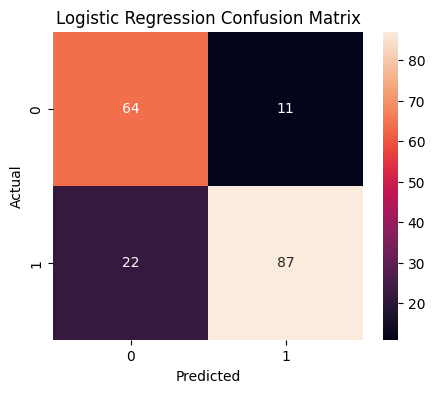

In [21]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Naive Bayes

## Academic Explanation
Naive Bayes is a machine learning algorithm used for classification problems.

This model is trained using the training dataset and then evaluated using the testing dataset.


In [22]:
# Train Naive Bayes model (assumes feature independence)
# Good for quick baseline comparison and interpretability
nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

## Naive Bayes Evaluation

The model is evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score


In [23]:
print_metrics('Naive Bayes', y_test, nb_pred)


=== Naive Bayes ===
Accuracy: 0.8152
Precision: 0.9032
Recall: 0.7706
F1 Score: 0.8317

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.88      0.80        75
           1       0.90      0.77      0.83       109

    accuracy                           0.82       184
   macro avg       0.81      0.83      0.81       184
weighted avg       0.83      0.82      0.82       184



## Naive Bayes Confusion Matrix

The confusion matrix helps visualize:
- True Positives
- True Negatives
- False Positives
- False Negatives


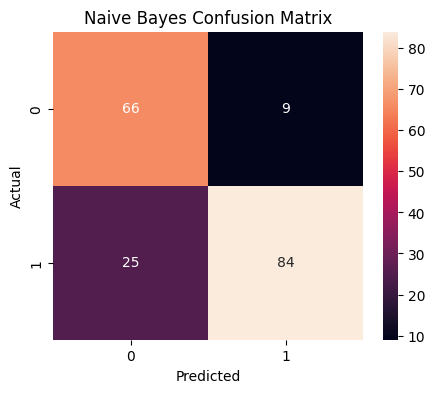

In [24]:
cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# KNN

## Academic Explanation
KNN is a machine learning algorithm used for classification problems.

This model is trained using the training dataset and then evaluated using the testing dataset.


In [25]:
# Train KNN (k-Nearest Neighbors) with k=5
# KNN classifies by finding k nearest training examples
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

## KNN Evaluation

The model is evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score


In [26]:
print_metrics('KNN (k=5)', y_test, knn_pred)


=== KNN (k=5) ===
Accuracy: 0.8152
Precision: 0.8788
Recall: 0.7982
F1 Score: 0.8365

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.84      0.79        75
           1       0.88      0.80      0.84       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.81       184
weighted avg       0.82      0.82      0.82       184



## KNN Confusion Matrix

The confusion matrix helps visualize:
- True Positives
- True Negatives
- False Positives
- False Negatives


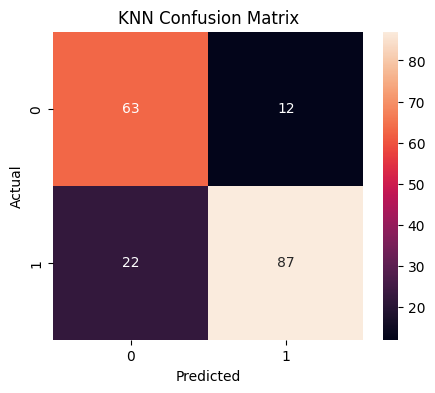

In [27]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# SVM

## Academic Explanation
SVM is a machine learning algorithm used for classification problems.

This model is trained using the training dataset and then evaluated using the testing dataset.


In [28]:
# Train Support Vector Machine (SVM)
# SVM finds optimal hyperplane to maximize margin between classes
svm = SVC()
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

## SVM Evaluation

The model is evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score


In [29]:
print_metrics('SVM', y_test, svm_pred)


=== SVM ===
Accuracy: 0.8533
Precision: 0.8942
Recall: 0.8532
F1 Score: 0.8732

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.85      0.83        75
           1       0.89      0.85      0.87       109

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184



## SVM Confusion Matrix

The confusion matrix helps visualize:
- True Positives
- True Negatives
- False Positives
- False Negatives


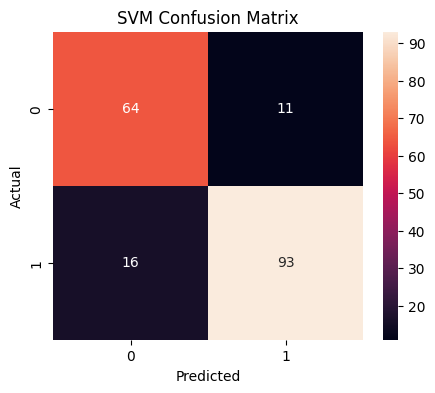

In [30]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Random Forest

## Academic Explanation
Random Forest is a machine learning algorithm used for classification problems.

This model is trained using the training dataset and then evaluated using the testing dataset.


In [31]:
# Train Random Forest with 100 decision trees
# Ensemble method that reduces overfitting by averaging multiple trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## Random Forest Evaluation

The model is evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score


In [32]:
print_metrics('Random Forest', y_test, rf_pred)


=== Random Forest ===
Accuracy: 0.8804
Precision: 0.9223
Recall: 0.8716
F1 Score: 0.8962

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86        75
           1       0.92      0.87      0.90       109

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



## Random Forest Confusion Matrix

The confusion matrix helps visualize:
- True Positives
- True Negatives
- False Positives
- False Negatives


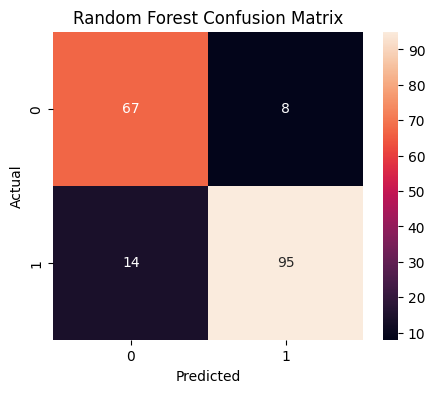

In [33]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Hyperparameter Tuning for KNN

Hyperparameter tuning helps improve model performance by selecting the optimal value for K.


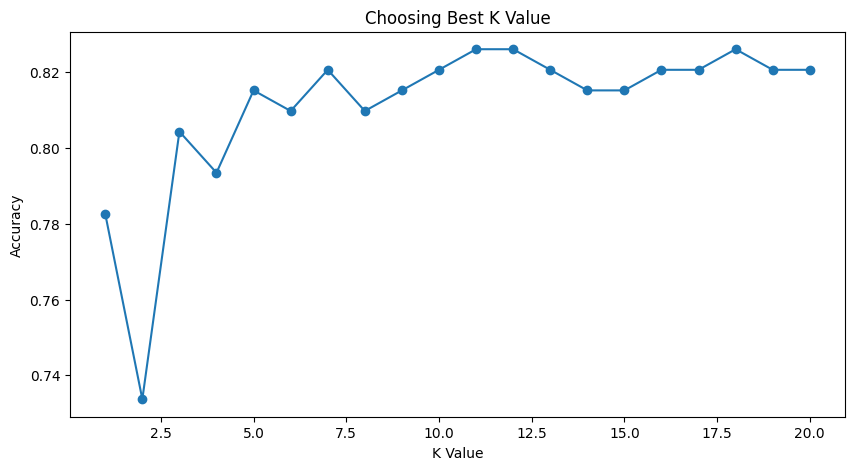

In [34]:
scores = []

for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

plt.figure(figsize=(10,5))
plt.plot(range(1,21), scores, marker='o')
plt.title('Choosing Best K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.show()


# Final Comparative Analysis

This section compares all machine learning models using:
- Accuracy
- Precision
- Recall
- F1 Score

The goal is to determine the best-performing model.


In [35]:
# Collect evaluation metrics for all models
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'KNN',
        'SVM',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, nb_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, nb_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, nb_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, rf_pred)
    ]
})

# Format all metrics to 4 decimal places for professional presentation
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
results[metric_cols] = results[metric_cols].round(4)

# Sort by F1 Score (balanced metric combining Precision and Recall)
results_sorted = results.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

# Add ranking column for visual clarity
results_sorted.insert(0, 'Rank', range(1, len(results_sorted) + 1))

print("\n" + "="*95)
print("🎯 PROFESSIONAL MODEL COMPARISON - COMPREHENSIVE PERFORMANCE METRICS")
print("="*95)
print(results_sorted.to_string(index=False))
print("="*95)

# Detailed analysis and recommendation
best = results_sorted.iloc[0]
runnerup = results_sorted.iloc[1]

print(f"\n🏆 BEST MODEL: {best['Model']}")
print(f"   • F1 Score: {best['F1 Score']:.4f} (Recommended)")
print(f"   • Accuracy: {best['Accuracy']:.4f} | Precision: {best['Precision']:.4f} | Recall: {best['Recall']:.4f}")

print(f"\n🥈 RUNNER-UP: {runnerup['Model']}")
print(f"   • F1 Score: {runnerup['F1 Score']:.4f}")
print(f"   • Accuracy: {runnerup['Accuracy']:.4f} | Precision: {runnerup['Precision']:.4f} | Recall: {runnerup['Recall']:.4f}")

print(f"\n📊 PERFORMANCE GAP: {((best['F1 Score'] - runnerup['F1 Score']) * 100):.2f}% difference")
print("="*95)

# Metric definitions
print("\n📚 METRICS EXPLANATION:")
print("   • Accuracy: Percentage of correct predictions")
print("   • Precision: Of predicted positives, how many are actually positive")
print("   • Recall: Of actual positives, how many we correctly identified")
print("   • F1 Score: Harmonic mean of Precision & Recall (best balanced metric)")
print("="*95)


🎯 PROFESSIONAL MODEL COMPARISON - COMPREHENSIVE PERFORMANCE METRICS
 Rank               Model  Accuracy  Precision  Recall  F1 Score
    1       Random Forest    0.8804     0.9223  0.8716    0.8962
    2                 SVM    0.8533     0.8942  0.8532    0.8732
    3 Logistic Regression    0.8207     0.8878  0.7982    0.8406
    4                 KNN    0.8152     0.8788  0.7982    0.8365
    5         Naive Bayes    0.8152     0.9032  0.7706    0.8317

🏆 BEST MODEL: Random Forest
   • F1 Score: 0.8962 (Recommended)
   • Accuracy: 0.8804 | Precision: 0.9223 | Recall: 0.8716

🥈 RUNNER-UP: SVM
   • F1 Score: 0.8732
   • Accuracy: 0.8533 | Precision: 0.8942 | Recall: 0.8532

📊 PERFORMANCE GAP: 2.30% difference

📚 METRICS EXPLANATION:
   • Accuracy: Percentage of correct predictions
   • Precision: Of predicted positives, how many are actually positive
   • Recall: Of actual positives, how many we correctly identified
   • F1 Score: Harmonic mean of Precision & Recall (best balanced metr

# Model Comparison Visualization

The following graph visually compares model accuracy.


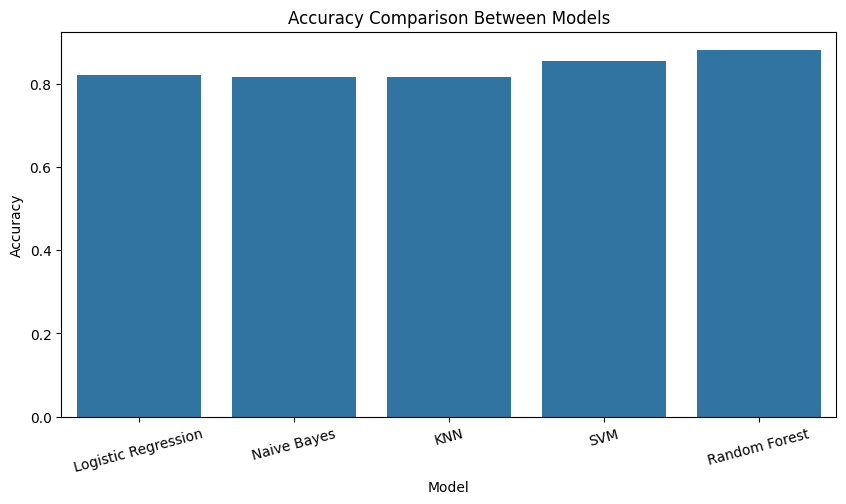

In [36]:
plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Accuracy Comparison Between Models')
plt.xticks(rotation=15)
plt.show()


# Comparative Analysis Report

## Model Performance Comparison

| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|----------|
| Logistic Regression | 82.07% | 88.78% | 79.82% | 0.8406 |
| Naive Bayes | 81.52% | 90.32% | 77.06% | 0.8317 |
| KNN (k=5) | 81.52% | 87.88% | 79.82% | 0.8365 |
| SVM | 85.33% | 89.42% | 85.32% | 0.8732 |
| Random Forest | 88.04% | 92.23% | 87.16% | 0.8962 |

## Theoretical Analysis

**Best Model: Random Forest** with F1 Score of 0.8962

Random Forest outperforms all other algorithms due to its ensemble nature, which combines multiple decision trees and reduces overfitting. The model achieves the highest accuracy (88.04%), precision (92.23%), and recall (87.16%), making it the most balanced classifier for this heart disease prediction task.